# Using a WGAN-GP to synthesize data
In this notebook, instead of a vanilla GAN, we use a WGAN-GP. This has a different objective function, defined in terms of the output of the discriminator directly, instead of using binary cross-entropy loss and add a penalty based on the gradient to try to get it close to 1-Lipschitz

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator, OutputHead
from gan.training import train_wgan_gp

#### Creating the data
We use a function to create this type of data set

In [2]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create data set with disk like clusters in circle around the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be generated
    centers : int
        number of clusters to be generated
    radius : float
        distance to origin of center of clusters
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    np.ndarray
        array of generated sample points
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32)

In [3]:
X = make_gaussian_mixture()

#### Training
We create instances of the Generator class and Discriminator class where the discriminator is used as a critic. For WGAN we scale the data to being in the $[-1,1]$ range and use $\tanh$ as the output activation function of the generator to get it into that range

In [15]:
# set a seed for reproducibility
torch.manual_seed(42)

In [ ]:
# create output head with tanh
heads = [OutputHead(dim=2,activation=nn.Tanh, decode=nn.Tanh, name="scaled_output")]
G = Generator(
    noise_dim=2,
    num_hidden_layers=2,
    output_heads=heads,
    hidden_dims=(128,128),
)

D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128)
)

In [ ]:
# scale data to [-1,1] range
X_min , X_max = X.max(axis=0), X.min(axis=0)
X_scaled = 2 * (X-X_min) / (X_max - X_min) - 1
X_torch = torch.tensor(X_scaled)
# train on the data
train_wgan_gp(
    X=X_torch,
    G=G,
    D=D,
    epochs=500,
    return_history=False
)

WGAN-GP training:   0%|          | 0/500 [00:00<?, ?it/s]

#### Visualization
We create a sample of synthetic data and then do a plot of the synthetic and real data to see how they compare.

In [18]:
@torch.no_grad()
def plot_samples(G, X_real, n=2000, title=None):
    """
    plot fake and real data
    Parameters
    ----------
    G: Generator
        used to generate fake points
    X_real : np.ndarray
        real data
    n : int
        number of points
    title : str | None
        optional title for plot
    """
    # generate fake data
    X_fake_raw = G.generate(n).cpu().numpy()
    # unscale the data
    X_fake = (X_fake_raw + 1) / 2 * (X_max - X_min) + X_min
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

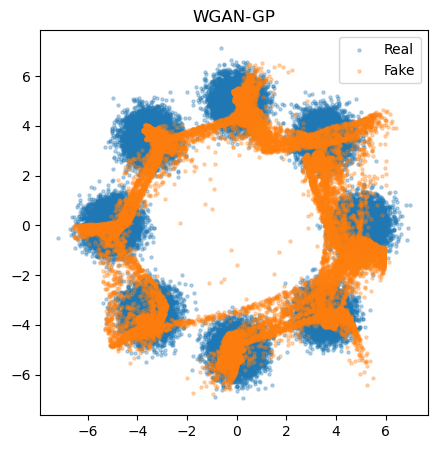

In [19]:
plot_samples(G, X, len(X), "WGAN-GP")